In [17]:
import numpy as np
import pandas as pd 
import os
os.chdir('..')  # Go up to project root
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
for dirname, _, filenames in os.walk('./kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [2]:
broadpeek = pd.read_csv('./kaggle/input/broad-peak.csv')
lhotse = pd.read_csv('./kaggle/input/lhotse.csv')
kangchenjunga = pd.read_csv('./kaggle/input/kangchenjunga.csv')
chooyu = pd.read_csv('./kaggle/input/cho-oyu.csv')
manaslu = pd.read_csv('./kaggle/input/manaslu.csv')
dhaulagiri = pd.read_csv('./kaggle/input/dhaulagiri-I.csv')
everest = pd.read_csv('./kaggle/input/everest.csv')
k2 = pd.read_csv('./kaggle/input/k2.csv')
nangaparbat = pd.read_csv('./kaggle/input/nanga-parbat.csv')
gasherbrum2 = pd.read_csv('./kaggle/input/gasherbrum-II.csv')
gasherbrum1 = pd.read_csv('./kaggle/input/gasherbrum-I.csv')
shishapangma = pd.read_csv('./kaggle/input/shishapangma.csv')
annapurna1 = pd.read_csv('./kaggle/input/annapurna-I.csv')
makalu = pd.read_csv('./kaggle/input/makalu.csv')

In [3]:
# Assign mountain in each dataset
broadpeek['mountain'] = 'Broad Peak'
lhotse['mountain'] = 'Lhotse'
kangchenjunga['mountain'] = 'Kangchenjunga'
chooyu['mountain'] = 'Chooyu'
manaslu['mountain'] = 'Manaslu'
dhaulagiri['mountain'] = 'Dhaulagiri I'
everest['mountain'] = 'Everest'
k2['mountain'] = 'K2'
nangaparbat['mountain'] = 'Nanga Parbat'
gasherbrum1['mountain'] = 'Gasherbrum I'
gasherbrum2['mountain'] = 'Gasherbrum II'
makalu['mountain'] = 'Makalu'
annapurna1['mountain'] = 'Annapurna I'
shishapangma['mountain'] = 'Shishapangma'

# Join datasets
allmountains = pd.concat([
    broadpeek, lhotse, kangchenjunga, chooyu, manaslu, dhaulagiri,
    everest, k2, nangaparbat, gasherbrum2, gasherbrum1, 
    shishapangma, annapurna1, makalu
], ignore_index=True)

In [4]:
# Format dates
allmountains['Date'] = pd.to_datetime(allmountains['Date'], format='mixed', errors='coerce')
allmountains['year'] = allmountains['Date'].dt.year
allmountains['month'] = allmountains['Date'].dt.month

# Check if any dates failed to parse
print(f"Missing dates: {allmountains['Date'].isna().sum()}")

# Deaths per year
allmountains['year'].value_counts().sort_index()

Missing dates: 0


year
1895     3
1905     3
1922     7
1924     4
1929     1
        ..
2017     9
2018    16
2019    25
2021    12
2022     4
Name: count, Length: 76, dtype: int64

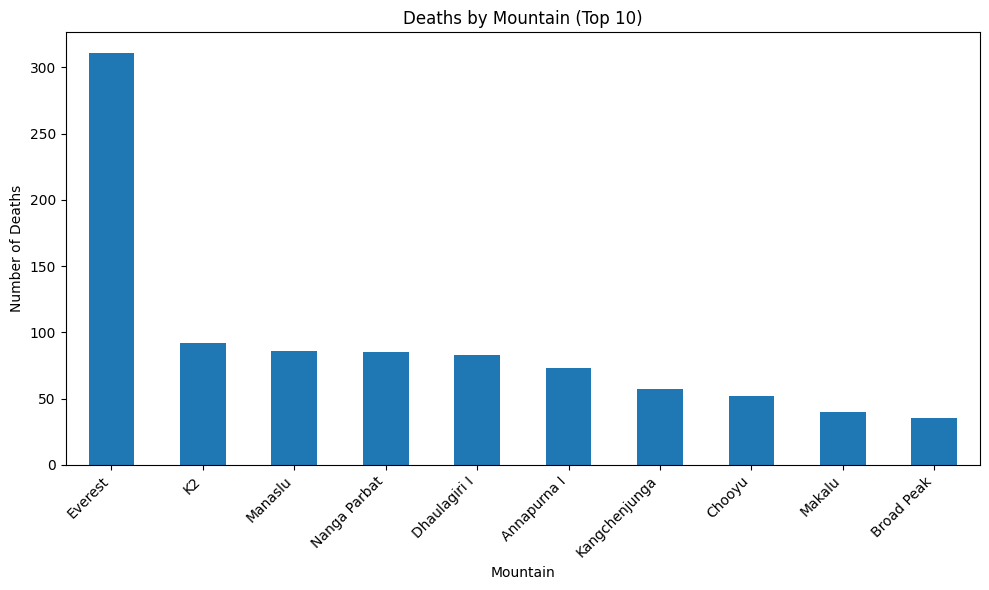

In [5]:
# Top 10 deadliest mountains
allmountains['mountain'].value_counts().head(10).plot(kind='bar', figsize=(10,6))
plt.title('Deaths by Mountain (Top 10)')
plt.xlabel('Mountain')
plt.ylabel('Number of Deaths')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Save plot
plt.savefig('images/deathsbymountain10.png', dpi=300, bbox_inches='tight')
plt.show()

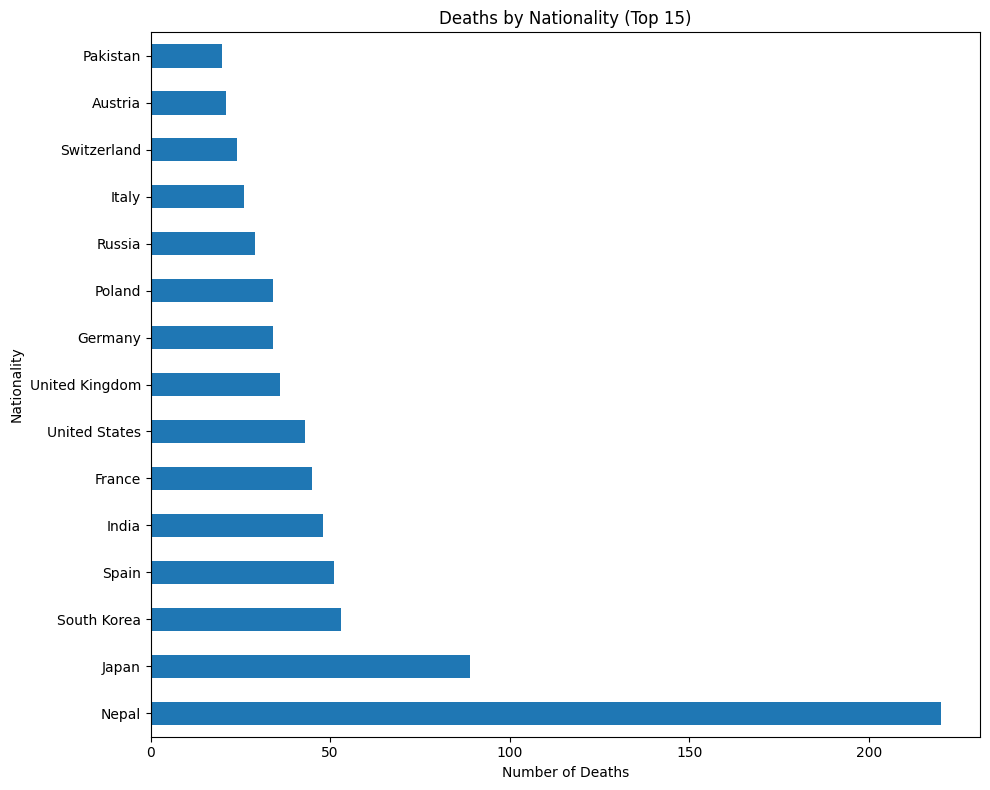

In [6]:
# Top 15 nationalities
allmountains['Nationality'].value_counts().head(15).plot(kind='barh', figsize=(10,8))
plt.title('Deaths by Nationality (Top 15)')
plt.xlabel('Number of Deaths')
plt.ylabel('Nationality')
plt.tight_layout()

# Save plot
plt.savefig('images/bynationality15.png', dpi=300, bbox_inches='tight')
plt.show()

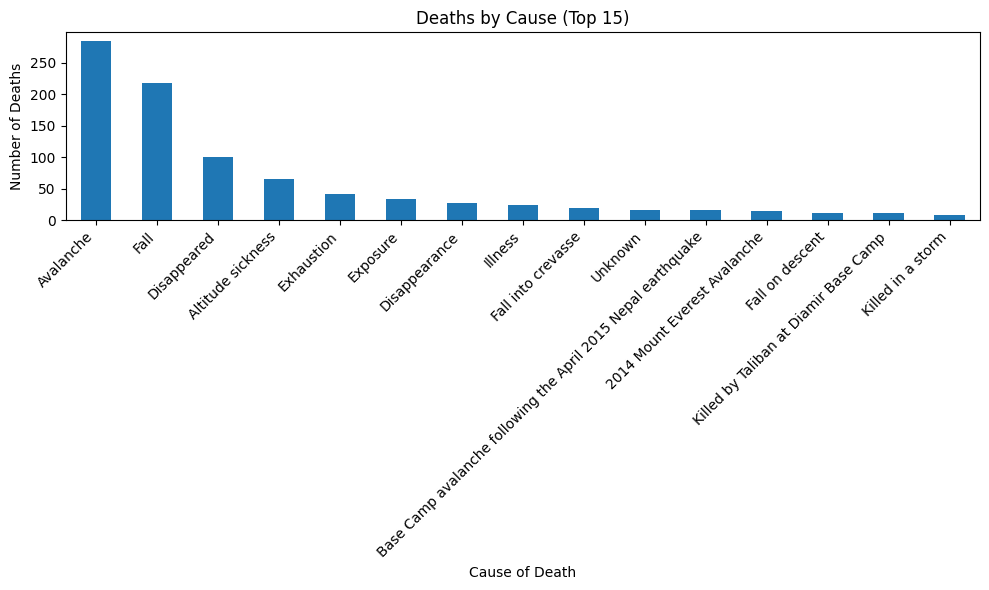

In [7]:
# Causes of death
allmountains['Cause of death'].value_counts().head(15).plot(kind='bar', figsize=(10,6))
plt.title('Deaths by Cause (Top 15)')
plt.xlabel('Cause of Death')
plt.ylabel('Number of Deaths')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Save plot
plt.savefig('images/causes15.png', dpi=300, bbox_inches='tight')
plt.show()

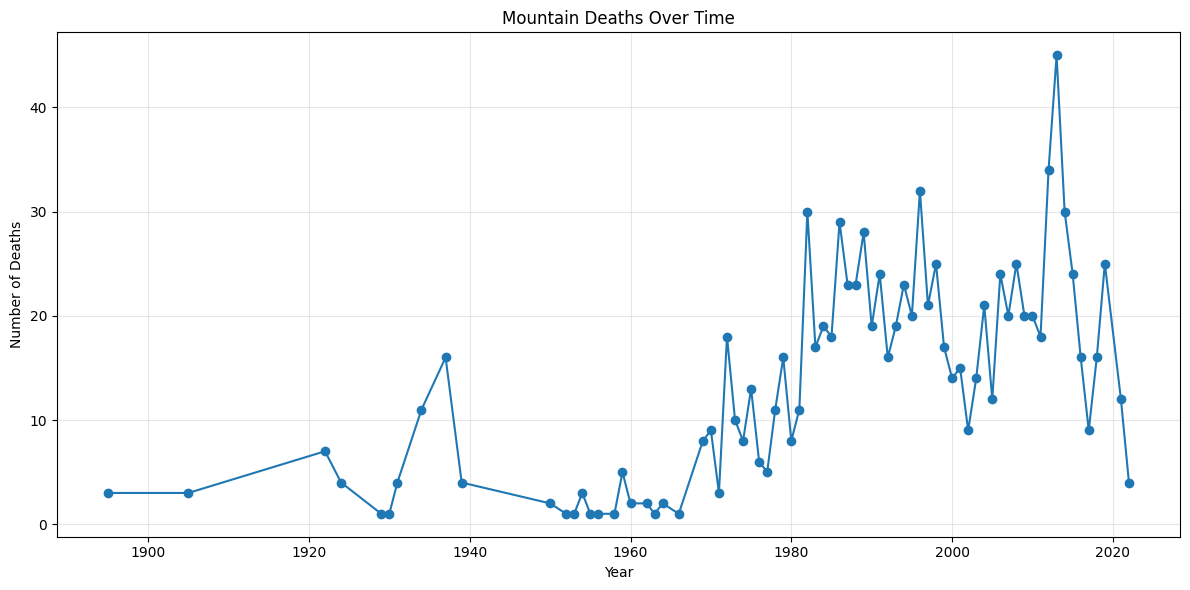

In [8]:
# Deaths over time (by year)
deaths_by_year = allmountains['year'].value_counts().sort_index()
plt.figure(figsize=(12,6))
plt.plot(deaths_by_year.index, deaths_by_year.values, marker='o')
plt.title('Mountain Deaths Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Deaths')
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save plot
plt.savefig('images/overtime.png', dpi=300, bbox_inches='tight')
plt.show()

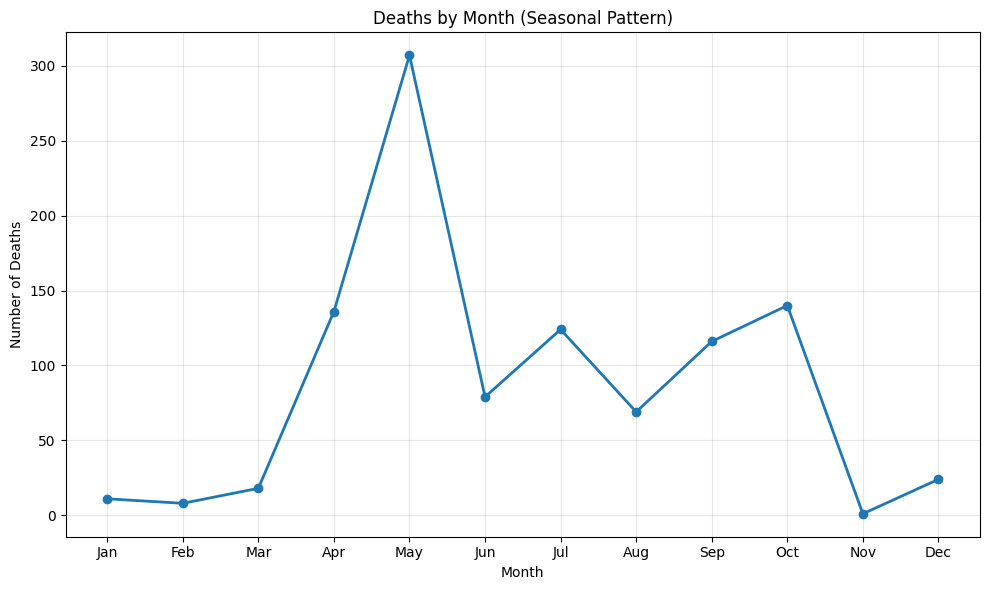

In [9]:
# Deaths by month (seasonal pattern)
deaths_by_month = allmountains['month'].value_counts().sort_index()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.figure(figsize=(10,6))
plt.plot(deaths_by_month.index, deaths_by_month.values, marker='o', linewidth=2)
plt.xticks(range(1, 13), month_names)
plt.title('Deaths by Month (Seasonal Pattern)')
plt.xlabel('Month')
plt.ylabel('Number of Deaths')
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save plot
plt.savefig('images/seasonalpattern.png', dpi=300, bbox_inches='tight')
plt.show()

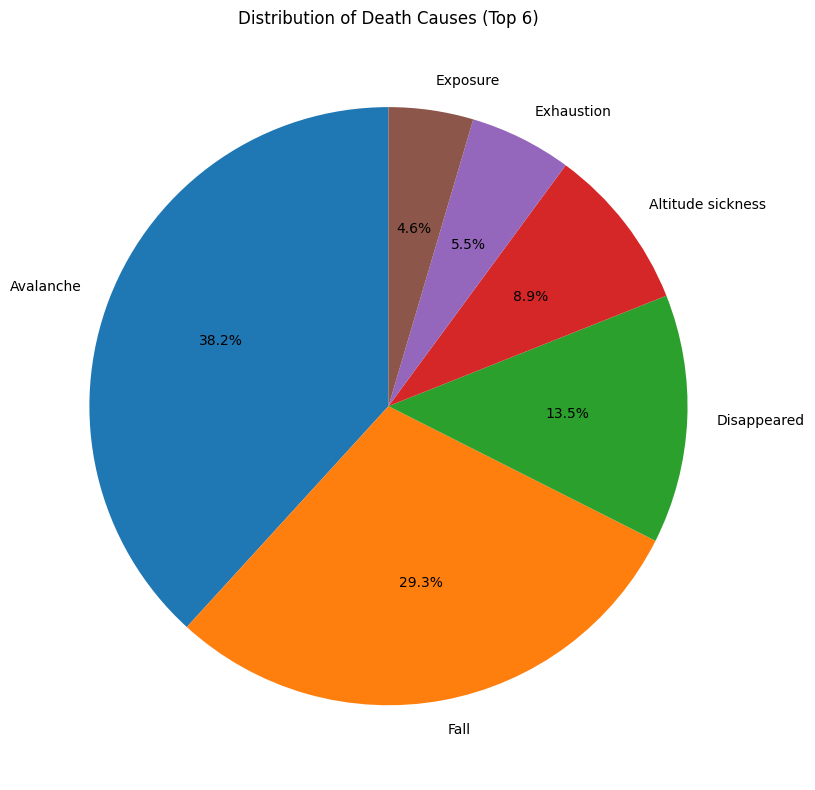

In [10]:
# Top causes of death
top_causes = allmountains['Cause of death'].value_counts().head(6)
plt.figure(figsize=(10,8))
plt.pie(top_causes.values, labels=top_causes.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Death Causes (Top 6)')
plt.tight_layout()

# Save plot
plt.savefig('images/deathcausespie.png', dpi=300, bbox_inches='tight')
plt.show()

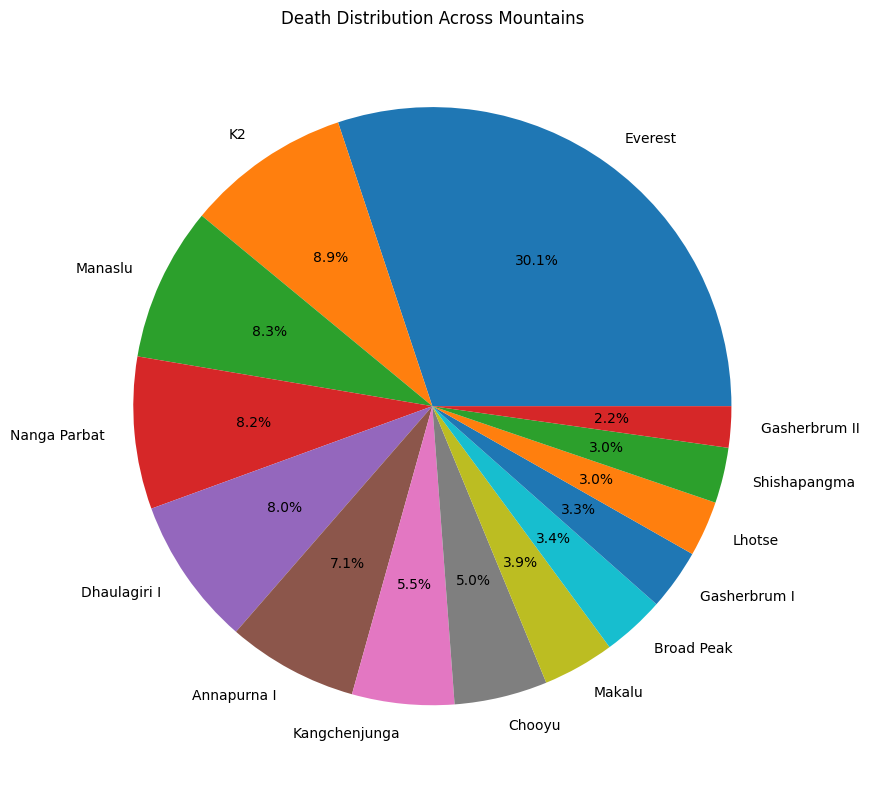

In [11]:
# Deaths by mountain
mountain_deaths = allmountains['mountain'].value_counts()
plt.figure(figsize=(12,8))
plt.pie(mountain_deaths.values, labels=mountain_deaths.index, autopct='%1.1f%%')
plt.title('Death Distribution Across Mountains')
plt.tight_layout()

# Save plot
plt.savefig('images/mountainpie.png', dpi=300, bbox_inches='tight')
plt.show()

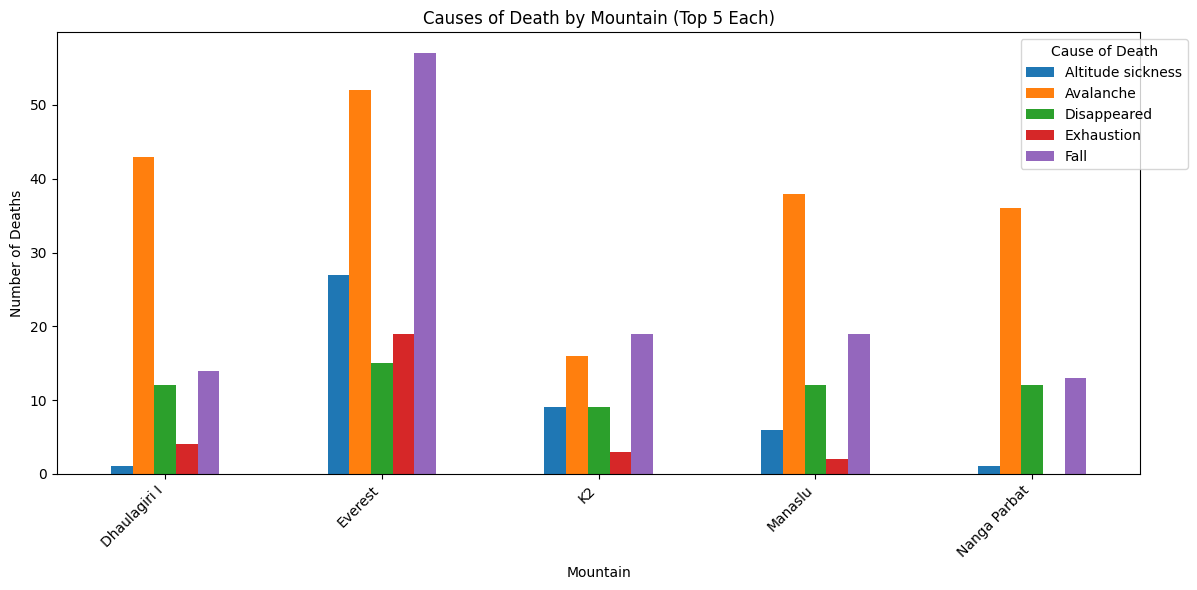

In [16]:
# Top 5 mountains vs top 5 causes of death
top_mountains = allmountains['mountain'].value_counts().head(5).index
top_causes = allmountains['Cause of death'].value_counts().head(5).index

filtered = allmountains[allmountains['mountain'].isin(top_mountains) & 
                        allmountains['Cause of death'].isin(top_causes)]

cause_mountain = pd.crosstab(filtered['mountain'], filtered['Cause of death'])
cause_mountain.plot(kind='bar', figsize=(12,6), stacked=False)
plt.title('Causes of Death by Mountain (Top 5 Each)')
plt.xlabel('Mountain')
plt.ylabel('Number of Deaths')
plt.legend(title='Cause of Death', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Save plot
plt.savefig('images/groupeddeathbymountain.png', dpi=300, bbox_inches='tight')
plt.show()